In [1]:
import anndata as ad
import os
import pandas as pd
import matplotlib.pyplot as plt

How embeddings were generated you can see here: https://github.com/theislab/op3_signatures/blob/main/notebooks/pca_embeddings/op3_embeddings.ipynb

Results were obtained across 10 seeds.

## Download results

In [2]:
def dict_to_pd(d):
    rows = []

    for outer_key, inner in d.items():
        row = {
            "dataset_id": inner["dataset_id"],
            "method_id": inner["method_id"],
        }
        
        # Use values from "d" as column names
        for col_name, value in zip(inner["metric_ids"], inner["metric_values"]):
            row[col_name] = value
            
        rows.append(row)
    
    df = pd.DataFrame(rows, index=d.keys())
    return df

In [3]:
methods_path = '../../data/benchmark/results/metrics/methods/'

In [4]:
file_name_err = 'mean_rowwise_error.h5ad'
file_name_corr = 'mean_rowwise_correlation.h5ad'

In [5]:
methods_err = {}
methods_corr = {}
subfolders = [
    'stability_pca_v1_64',
    'stability_pca_v2_64',
    'stability_pca_v3_64',
    'stability_pca_v4_64',
    'stability_pca_v2_128',
    'stability_pca_v3_128',
    'stability_pca_v4_128',
]
for item in os.listdir(methods_path):
    if ('mol_emb_subsample' in item) and ('pca' in item):
        for s in subfolders:
            stability_path = methods_path + item + '/' + s
            for seed in os.listdir(stability_path):
                
                err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
                corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
                methods_err[item +  '_' + s.split('stability')[1] +  '_' + seed] = err
                methods_corr[item +  '_' + s.split('stability')[1] + '_' + seed] = corr
    elif ('mol_emb_subsample' in item) and ('none' in item):
        stability_path = methods_path + item + '/stability_pca_v2_64'
        for seed in os.listdir(stability_path):
                
            err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
            corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
            methods_err[item +  '_' + seed] = err
            methods_corr[item + '_' + seed] = corr

In [6]:
df_method_err = dict_to_pd(methods_err)
df_method_corr = dict_to_pd(methods_corr)

In [7]:
df_method_err

,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_fixed__pca_v1_64_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.818788,0.593747
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_fixed__pca_v1_64_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.817681,0.593239
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_fixed__pca_v1_64_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.816590,0.592756
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_fixed__pca_v1_64_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.816726,0.592357
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_fixed__pca_v1_64_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.817987,0.593504
...,...,...,...,...
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_trainable__pca_v4_128_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.813424,0.590352
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_trainable__pca_v4_128_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.814491,0.590703
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_trainable__pca_v4_128_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.815255,0.591310
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_trainable__pca_v4_128_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.812519,0.589598


In [8]:
df_method_err['method_name'] = df_method_err.index.str.split('_seed_').str[0]
df_method_err['seed'] = df_method_err.index.str.split('_seed_').str[1].astype(int)
df_method_corr['method_name'] = df_method_corr.index.str.split('_seed_').str[0]
df_method_corr['seed'] = df_method_corr.index.str.split('_seed_').str[1].astype(int)

## Mean rowwise error

### Methods

In [9]:
df_method_err.sort_values(by="mean_rowwise_rmse")

,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae,method_name,seed
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_trainable__pca_v2_64_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.803833,0.582328,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_concat_not_dense__pca_v2_64_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.804015,0.579297,nn_retraining_with_pseudolabels_mol_emb_subsam...,11
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_concat_not_dense__pca_v2_64_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.804585,0.580010,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_concat_not_dense__pca_v2_64_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.805071,0.580386,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_concat_not_dense__pca_v2_64_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.805168,0.580032,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
...,...,...,...,...,...,...
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_concat_dense__pca_v1_64_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.831395,0.602360,nn_retraining_with_pseudolabels_mol_emb_subsam...,10
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_concat_dense__pca_v1_64_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.831843,0.602350,nn_retraining_with_pseudolabels_mol_emb_subsam...,14
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_concat_dense__pca_v1_64_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.831965,0.602403,nn_retraining_with_pseudolabels_mol_emb_subsam...,1
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_concat_dense__pca_v1_64_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.832216,0.602471,nn_retraining_with_pseudolabels_mol_emb_subsam...,0


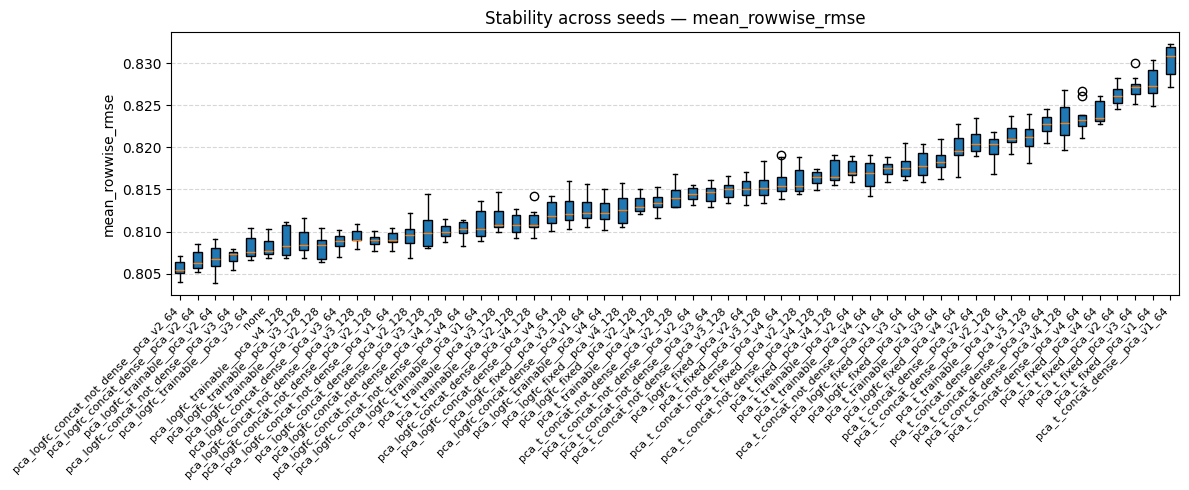

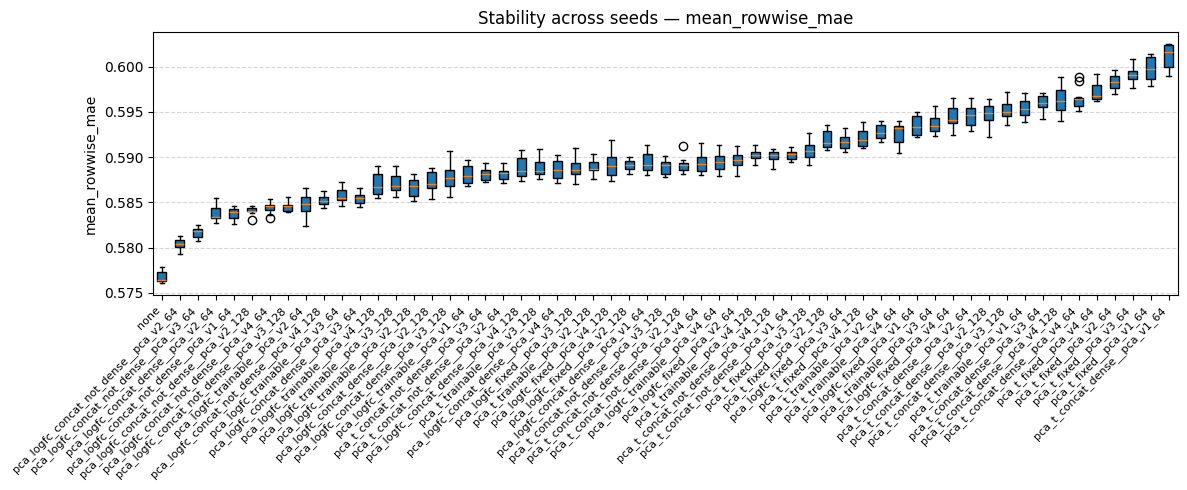

In [10]:
metrics = ["mean_rowwise_rmse", "mean_rowwise_mae"]
for metric in metrics:
    # collect values per method, ordered by median
    methods_ordered = (
        df_method_err.groupby("method_name")[metric]
        .median()
        .sort_values()
        .index.tolist()
    )
    data_per_method = [
        df_method_err.loc[df_method_err["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    fig, ax = plt.subplots(figsize=(12, 5))
    bp = ax.boxplot(data_per_method, patch_artist=True, vert=True)
    ax.set_xticks(range(1, len(methods_ordered) + 1))
    ax.set_xticklabels(
        # strip the long common prefix for readability
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    ax.set_ylabel(metric)
    ax.set_title(f"Stability across seeds — {metric}")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## Mean rowwise correlation

### Methods

In [11]:
df_method_corr.sort_values(by="mean_rowwise_pearson", ascending=False)
#df_method_corr.sort_values(by="mean_rowwise_spearman", ascending=False)

,dataset_id,method_id,mean_rowwise_pearson,mean_rowwise_spearman,mean_rowwise_cosine,method_name,seed
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_logfc_trainable__pca_v4_128_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_lo...,0.475518,0.447579,0.478370,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_none_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_none,0.475317,0.448204,0.478469,nn_retraining_with_pseudolabels_mol_emb_subsam...,13
nn_retraining_with_pseudolabels_mol_emb_subsample_none_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_none,0.475020,0.448301,0.478202,nn_retraining_with_pseudolabels_mol_emb_subsam...,11
nn_retraining_with_pseudolabels_mol_emb_subsample_none_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_none,0.474886,0.448357,0.478035,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_none_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_none,0.474699,0.447798,0.477878,nn_retraining_with_pseudolabels_mol_emb_subsam...,12
...,...,...,...,...,...,...,...
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_fixed__pca_v3_64_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.438623,0.413266,0.441781,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_fixed__pca_v3_64_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.438029,0.412347,0.441180,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_fixed__pca_v3_64_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.437852,0.412812,0.440992,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_pca_t_fixed__pca_v3_64_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_pca_t_...,0.437662,0.412261,0.440822,nn_retraining_with_pseudolabels_mol_emb_subsam...,13


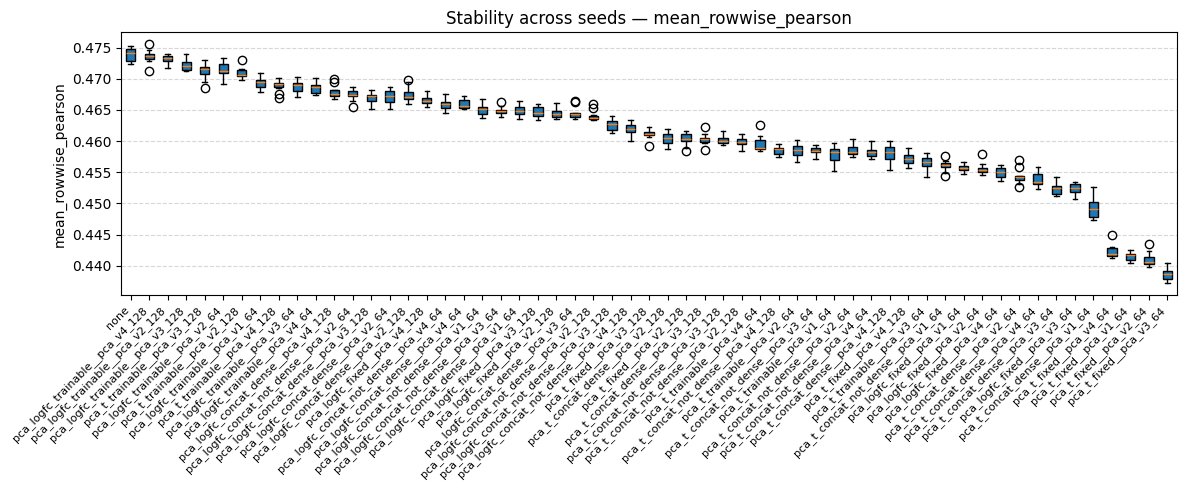

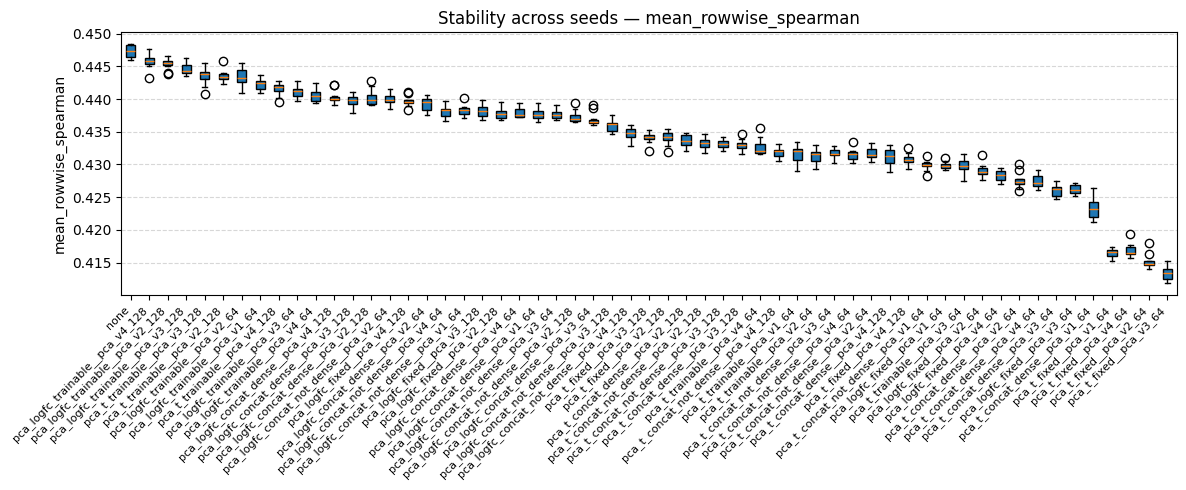

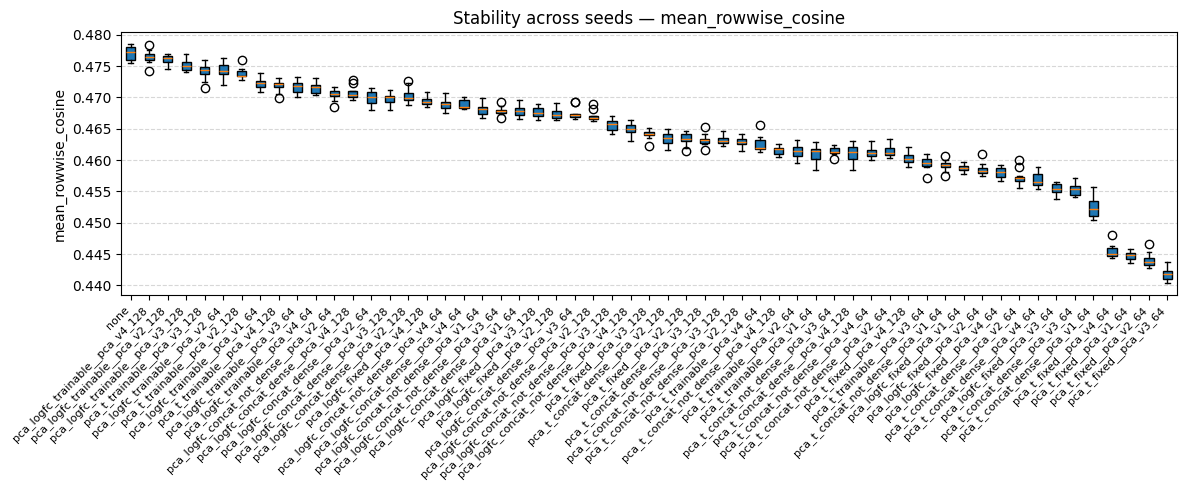

In [12]:
corr_metrics = ["mean_rowwise_pearson", "mean_rowwise_spearman", "mean_rowwise_cosine"]
for metric in corr_metrics:
    # higher correlation is better → sort descending
    methods_ordered = (
        df_method_corr.groupby("method_name")[metric]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    data_per_method = [
        df_method_corr.loc[df_method_corr["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    fig, ax = plt.subplots(figsize=(12, 5))
    bp = ax.boxplot(data_per_method, patch_artist=True, vert=True)
    ax.set_xticks(range(1, len(methods_ordered) + 1))
    ax.set_xticklabels(
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    ax.set_ylabel(metric)
    ax.set_title(f"Stability across seeds — {metric}")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()